In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = pd.read_csv("final_data_2009_2017.csv")

In [3]:
df["hq_location"].value_counts()

hq_location
US        554
Europe    179
Name: count, dtype: int64

## Statistical Table for Performance Metrics (IRR, DPI, TVPI)

In [4]:
import pandas as pd

# Define metrics and readable names
metrics = {
    'net_irr_pcent': 'Net IRR',
    'distr_dpi_pcent': 'DPI',
    'tvpi_pcent': 'TVPI'
}
locations = {
    'Overall': df,
    'Europe': df[df['hq_location'] == 'Europe'],
    'USA': df[df['hq_location'] == 'US']
}

# For each metric, generate LaTeX table with quartiles
for col, label in metrics.items():
    rows = []
    for region, subset in locations.items():
        s = subset[col].dropna()
        rows.append({
            'Region': region,
            'N': len(s),
            'Mean': round(s.mean(), 2),
            'Median': round(s.median(), 2),
            'Std. Dev.': round(s.std(), 2),
            'Min': round(s.min(), 2),
            'Q1': round(s.quantile(0.25), 2),
            'Q3': round(s.quantile(0.75), 2),
            'Max': round(s.max(), 2)
        })

    table_df = pd.DataFrame(rows)

    # Export as LaTeX file
    table_df.to_latex(
        index=False,
        float_format="%.2f",
        caption=f"{label} by Region",
        label=f"tab:{col}_summary",
        column_format='lrrrrrrrr',
        buf=f"{col}_summary.tex",
        bold_rows=False
    )

## Plotting DPI, IRR, TVPI over time

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Load your data
df = pd.read_csv("final_data_2009_2017.csv")

# Aggregate by vintage
performance_by_vintage = df.groupby("vintage")[["net_irr_pcent", "distr_dpi_pcent", "tvpi_pcent"]].mean().reset_index()

# Plot setup
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
plt.rcParams["font.family"] = "serif"

# Left y-axis: DPI & TVPI
ax1.plot(
    performance_by_vintage["vintage"], performance_by_vintage["distr_dpi_pcent"],
    color="black", linestyle="--", marker="s", label="DPI", linewidth=1.8
)
ax1.plot(
    performance_by_vintage["vintage"], performance_by_vintage["tvpi_pcent"],
    color="black", linestyle=":", marker="^", label="TVPI", linewidth=1.8
)
ax1.set_xlabel("Vintage Year")
ax1.set_ylabel("DPI / TVPI")
ax1.set_ylim(0, performance_by_vintage[["distr_dpi_pcent", "tvpi_pcent"]].max().max() * 1.15)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Right y-axis: IRR
ax2 = ax1.twinx()
ax2.plot(
    performance_by_vintage["vintage"], performance_by_vintage["net_irr_pcent"],
    color="black", linestyle="-", marker="o", label="Net IRR", linewidth=1.8
)
ax2.set_ylabel("Net IRR")
ax2.yaxis.set_major_formatter(PercentFormatter())

# Turn off grid lines
ax1.grid(False)
ax2.grid(False)

# Combine legends manually
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9, frameon=False)

# Final formatting
fig.tight_layout()
fig.savefig("vintage_performance_dualaxis.pdf", format="pdf", bbox_inches="tight")
plt.close()

## Counts by Vintage Year

In [6]:
# First table: Vintage year counts
table1 = df.groupby('vintage').agg(
    US_funds = ('hq_location', lambda x: (x == 'US').sum()),
    European_funds = ('hq_location', lambda x: (x == 'Europe').sum()),
    Total_funds = ('hq_location', 'count')
).reset_index()

# Export as LaTeX
table1.to_latex(
    index=False,
    caption="Number of Funds by Vintage Year and Region",
    label="tab:vintage_counts",
    column_format='lrrr',
    float_format="%.0f",
    buf="vintage_fund_counts.tex"
)


## Statistical Table for Fund Size and Age at Report 

In [7]:
# Define metrics and regions
metrics = {
    'final_size_usd': 'Fund Size (USDm)',
    'fund_age_at_report': 'Fund Age at Report'
}
regions = {
    'Overall': df,
    'Europe': df[df['hq_location'] == 'Europe'],
    'USA': df[df['hq_location'] == 'US']
}

# Collect stats
rows = []

for var, label in metrics.items():
    for region, subset in regions.items():
        s = subset[var].dropna()
        rows.append({
            'Variable': label,
            'Region': region,
            'N': len(s),
            'Mean': round(s.mean(), 2),
            'Median': round(s.median(), 2),
            'Std. Dev.': round(s.std(), 2),
            'Min': round(s.min(), 2),
            'Q1': round(s.quantile(0.25), 2),
            'Q3': round(s.quantile(0.75), 2),
            'Max': round(s.max(), 2)
        })

table2 = pd.DataFrame(rows)

# Export as LaTeX
table2.to_latex(
    index=False,
    caption="Descriptive Statistics for Fund Size and Fund Age by Region",
    label="tab:fund_characteristics",
    column_format='llrrrrrrrr',
    float_format="%.2f",
    buf="fund_characteristics_summary.tex"
)


## Code to investige the abnormal fund sizes

In [8]:
info = pd.read_csv("Fund Details.csv",low_memory=False)
details = pd.read_csv("Manger Details.csv",low_memory=False)

In [9]:
fund_size_test = pd.merge(info, details, on = "firm_id", how = "inner")

In [10]:
VC_CORE = {"Venture (General)", "Early Stage", "Early Stage: Seed", "Early Stage: Start-up"}

fund_size_test = (fund_size_test
           .loc[fund_size_test["fund_type"].isin(VC_CORE)]               # Filter auf Fund-Typ
           .assign(vintage=lambda d: pd.to_numeric(d["vintage"], errors="coerce"))
           .loc[lambda d: (d["vintage"] >= 2009) & (d["vintage"] <= 2017)]               # Vintage-Cut
           .copy())


In [11]:
fund_size_test

,firm_id,fund_id,fund_name,firm_name,vintage,fund_type,fundraising_launch_date,local_currency,target_size_lc,target_size_usd,...,averagetransactionsperannummax,welcomebusinessplan,businessplanlocation,geofocus,countryfocus,industryfocus,isminorityowned,iswomenowned,listed_firm,firmethos
447,299,793,Forward Ventures IV,Forward Ventures,2010.0,Venture (General),20030410.0,USD,NaN,NaN,...,NaN,NaN,NaN,Europe; Global; North America; China; Germany; US,NaN,Business Services;Diversified;Financial Servic...,False,False,False,NaN
1366,278307,86898,Ji'nan Zongmei Fund,Shandong Wenzi Capital,2017.0,Venture (General),NaN,RMB,NaN,NaN,...,NaN,NaN,NaN,China,NaN,Consumer Discretionary;Education/Training;Trav...,False,False,False,NaN
2068,4658,4062,Horizon Ventures Fund II,Horizon Founders Capital,2014.0,Early Stage: Start-up,20121019.0,USD,NaN,NaN,...,NaN,NaN,NaN,North America; US,NaN,Business Support Services;Marketing/Advertisin...,False,False,False,NaN
2556,6335,5160,North East Proof of Concept Fund,Northstar Ventures,2009.0,Early Stage,NaN,GBP,NaN,NaN,...,NaN,NaN,NaN,Global; UK,NaN,Business Support Services;Marketing/Advertisin...,False,False,False,NaN
2632,310086,101894,Shanghai FTZ Fund III,FTZ Fund,2017.0,Venture (General),NaN,RMB,NaN,NaN,...,NaN,NaN,NaN,China,NaN,Business Services;Business Support Services;Co...,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71491,204952,228967,Jinan Rongjulong Fund,Horus Capital,2015.0,Venture (General),NaN,RMB,NaN,NaN,...,NaN,NaN,NaN,China,NaN,Consumer Discretionary;Consumer Products;Consu...,False,False,False,NaN
71524,731220,229063,Xiamen Acorn Energy Conservation and Environme...,Acorn Capital,2014.0,Venture (General),NaN,RMB,NaN,NaN,...,NaN,NaN,NaN,China,NaN,Information Technology;Electronics;Semiconduct...,False,False,False,NaN
71658,180147,229338,Ningbo Meishan Bonded Port Area Jingyue Fund,Qianhai Wutong Mergers and Acquisitions Fund,2016.0,Venture (General),NaN,RMB,NaN,NaN,...,NaN,NaN,NaN,China,NaN,Business Services;Business Support Services;Ma...,False,False,False,NaN
71717,426975,229449,Twosun Greenpoint Mittelstand Fund II,Twosun Invest,2014.0,Venture (General),NaN,KRW,NaN,NaN,...,NaN,NaN,NaN,South Korea,NaN,Renewable Energy;Information Technology;Electr...,False,False,False,NaN


In [12]:
# Liste europäischer Länder (ggf. erweitern)
EUROPE = {
    'Austria','Belgium','Bulgaria','Croatia','Czech Republic','Cyprus','Denmark',
    'Estonia','Finland','France','Germany','Greece','Hungary',
    'Ireland','Italy','Latvia','Lithuania','Luxembourg','Malta','Netherlands',
    'Norway','Poland','Portugal','Romania','Slovakia','Slovenia',
    'Spain','Sweden','Switzerland','United Kingdom','UK'
}

US = {'United States', 'US'}

def hq_location(country):
    if pd.isna(country):         return 'Other'   # Unknown zählt zu Other
    if country in US:            return 'US'
    if country in EUROPE:        return 'Europe'
    return 'Other'

fund_size_test["hq_location"] = fund_size_test["firmcountry"].apply(hq_location)

# Drop all rows whose mapped HQ location is "Other"
fund_size_test = fund_size_test[fund_size_test["hq_location"] != "Other"].copy()

# (Optional) reset the index if you want a clean sequential index
fund_size_test.reset_index(drop=True, inplace=True)

In [13]:
fund_size_test

,firm_id,fund_id,fund_name,firm_name,vintage,fund_type,fundraising_launch_date,local_currency,target_size_lc,target_size_usd,...,welcomebusinessplan,businessplanlocation,geofocus,countryfocus,industryfocus,isminorityowned,iswomenowned,listed_firm,firmethos,hq_location
0,299,793,Forward Ventures IV,Forward Ventures,2010.0,Venture (General),20030410.0,USD,NaN,NaN,...,NaN,NaN,Europe; Global; North America; China; Germany; US,NaN,Business Services;Diversified;Financial Servic...,False,False,False,NaN,US
1,4658,4062,Horizon Ventures Fund II,Horizon Founders Capital,2014.0,Early Stage: Start-up,20121019.0,USD,NaN,NaN,...,NaN,NaN,North America; US,NaN,Business Support Services;Marketing/Advertisin...,False,False,False,NaN,US
2,6335,5160,North East Proof of Concept Fund,Northstar Ventures,2009.0,Early Stage,NaN,GBP,NaN,NaN,...,NaN,NaN,Global; UK,NaN,Business Support Services;Marketing/Advertisin...,False,False,False,NaN,Europe
3,6559,5426,Aperture Venture Partners II,Aperture Venture Partners,2009.0,Venture (General),NaN,USD,40.0,40.0,...,NaN,NaN,US,NaN,Healthcare;Biotechnology;Healthcare IT;Medical...,False,False,False,NaN,US
4,4571,5504,Blumberg Capital II,Blumberg Capital,2009.0,Early Stage,20070110.0,USD,100.0,100.0,...,NaN,NaN,Europe; Global; Israel; Middle East; North Ame...,NaN,Business Services;Business Support Services;Co...,False,False,False,NaN,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3518,96512,224737,ICQ Ethos AUS RE,ICONIQ Capital,2015.0,Venture (General),NaN,NaN,NaN,NaN,...,NaN,NaN,Emerging Markets; Europe; Global; North Americ...,NaN,Business Support Services;Marketing/Advertisin...,False,False,False,NaN,US
3519,620023,224748,Edelweiss Ventures Fund,Republic,2017.0,Venture (General),NaN,NaN,NaN,NaN,...,NaN,NaN,Global; US,NaN,Information Technology;Software;Real Estate,False,False,False,NaN,US
3520,102430,226653,Chariot of Helios Fund,Lemnos Labs,2013.0,Early Stage,NaN,USD,15.0,15.0,...,NaN,NaN,Global; North America; US,NaN,Marketing/Advertising;Business Support Service...,False,False,False,NaN,US
3521,102430,226654,Thunderbolt of Zeus Fund,Lemnos Labs,2012.0,Early Stage,NaN,USD,6.0,6.0,...,NaN,NaN,Global; North America; US,NaN,Marketing/Advertising;Business Support Service...,False,False,False,NaN,US


In [14]:
import pandas as pd

# Assume your DataFrame is called 'fund_size_test'
# and contains columns: 'final_size_usd', 'hq_location'

# Define regions
regions = {
    'Europe': fund_size_test[fund_size_test['hq_location'] == 'Europe'],
    'USA': fund_size_test[fund_size_test['hq_location'] == 'US']
}

# Collect summary stats
rows = []

for region, subset in regions.items():
    s = subset['final_size_usd'].dropna()
    rows.append({
        'Region': region,
        'N': len(s),
        'Mean': round(s.mean(), 2),
        'Median': round(s.median(), 2),
        'Std. Dev.': round(s.std(), 2),
        'Min': round(s.min(), 2),
        'Q1': round(s.quantile(0.25), 2),
        'Q3': round(s.quantile(0.75), 2),
        'Max': round(s.max(), 2)
    })

# Create LaTeX table
table = pd.DataFrame(rows)
table.to_latex(
    index=False,
    caption="Fund Size by Region in Million USD before merging Performance Data",
    label="tab:fund_size_region",
    column_format='lrrrrrrrr',
    float_format="%.2f",
    buf="fund_size_summary.tex"
)


## Brown-Forsythe-Test for Appendix

In [15]:
import pandas as pd
from scipy.stats import levene

# Define metrics and readable labels
metrics = {
    'net_irr_pcent': 'Net IRR',
    'distr_dpi_pcent': 'DPI',
    'tvpi_pcent': 'TVPI'
}

results = []

for var, label in metrics.items():
    us = df[df["hq_location"] == "US"][var].dropna()
    eu = df[df["hq_location"] == "Europe"][var].dropna()
    
    stat, pval = levene(us, eu, center='median')  # Brown–Forsythe
    results.append({
        "Metric": label,
        "US N": len(us),
        "Europe N": len(eu),
        "W Statistic": round(stat, 3),
        "p-value": f"{pval:.4f}"
    })

# Create DataFrame
table = pd.DataFrame(results)

# Export to LaTeX
table.to_latex(
    index=False,
    caption="Brown--Forsythe Test for Equality of Variances between US and European Funds",
    label="tab:variance_tests",
    column_format="lrrrrr",
    float_format="%.3f",
    buf="variance_tests.tex"
)


## Distributions for Appendix

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv("final_data_2009_2017.csv")

# Set plot style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["font.family"] = "serif"

# Define metrics and labels
metrics = {
    'net_irr_pcent': 'Net IRR (%)',
    'distr_dpi_pcent': 'DPI (%)',
    'tvpi_pcent': 'TVPI (%)'
}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (var, label) in zip(axes, metrics.items()):
    sns.histplot(df[var].dropna(), kde=True, ax=ax, color="black", bins=40)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("performance_distributions.pdf", format="pdf", bbox_inches="tight")
plt.close()


## Checking missing samples

In [17]:
metrics = ["distr_dpi_pcent", "tvpi_pcent", "net_irr_pcent"]

for col in metrics:
    missing_rate = df.groupby("hq_location")[col].apply(lambda x: x.isna().mean() * 100).round(2)
    print(f"Missing % for {col}:\n{missing_rate}\n")


Missing % for distr_dpi_pcent:
hq_location
Europe    6.70
US        8.84
Name: distr_dpi_pcent, dtype: float64

Missing % for tvpi_pcent:
hq_location
Europe    11.17
US        10.47
Name: tvpi_pcent, dtype: float64

Missing % for net_irr_pcent:
hq_location
Europe    14.53
US        10.65
Name: net_irr_pcent, dtype: float64



## Creating Dummies for Specialist, hq_location and vintage

In [18]:
# Add dummy for Specialist
df["Specialist"] = (df["industry_specialisation"] == "Specialist").astype(int)

# Add location dummies: Europe, US, etc.
df["Europe"] = (df["hq_location"] == "Europe").astype(int)

vintage_dummies = pd.get_dummies(df["vintage"], prefix="vintage", drop_first=False).astype(int)
df = pd.concat([df, vintage_dummies], axis=1)

In [19]:
df["industry_specialisation"].value_counts()

industry_specialisation
Generalist    455
Specialist    278
Name: count, dtype: int64

## Building Models 1 to 4

In [20]:
def prepare_data_general(df, dependent_var, model_id):
    df_model = df[df[dependent_var].notna()].copy()

    if model_id == 1:
        regressors = ["Europe"] + [f"vintage_{y}" for y in range(2010, 2018)]

    elif model_id == 2:
        df_model["Europe_x_Vintage"] = df_model["Europe"] * df_model["vintage"]
        regressors = ["Europe", "vintage", "Europe_x_Vintage"]

    elif model_id == 3:
        df_model["Europe_x_Specialist"] = df_model["Europe"] * df_model["Specialist"]
        regressors = ["Europe", "Specialist", "Europe_x_Specialist"] + [f"vintage_{y}" for y in range(2010, 2018)]

    elif model_id == 4:
        df_model = df_model[df_model["final_size_usd"].notna() & (df_model["final_size_usd"] > 0)].copy()
        df_model["log_size"] = np.log(df_model["final_size_usd"])
        df_model["log_size_sq"] = df_model["log_size"] ** 2
        df_model["Europe_x_logsize"] = df_model["Europe"] * df_model["log_size"]
        df_model["Europe_x_logsize_sq"] = df_model["Europe"] * df_model["log_size_sq"]
        regressors = ["Europe", "log_size", "log_size_sq", "Europe_x_logsize", "Europe_x_logsize_sq"] + [f"vintage_{y}" for y in range(2010, 2018)]

    else:
        raise ValueError("Invalid model_id")

    X = sm.add_constant(df_model[regressors])
    y = df_model[dependent_var]
    clusters = df_model["firm_id"]
    return X, y, clusters


def run_model(df, dependent_var, model_id):
    X, y, clusters = prepare_data_general(df, dependent_var, model_id)
    model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": clusters})
    return model


In [21]:
def extract_combined_regression_table(models: dict, filename: str, caption: str = "", label: str = "", return_df=False):
    def star(p):
        return '***' if p <= 0.01 else '**' if p <= 0.05 else '*' if p <= 0.1 else ''

    relevant_vars = []
    for model in models.values():
        for var in model.params.index:
            if not var.startswith("vintage_"):
                relevant_vars.append(var)
    relevant_vars = list(dict.fromkeys(relevant_vars))

    rows = []
    for var in relevant_vars:
        row = [var]
        for model in models.values():
            if var in model.params:
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]
                row += [f"{coef:.2f}{star(pval)}", f"{se:.2f}", f"{pval:.3f}"]
            else:
                row += ["", "", ""]
        rows.append(row)

    r2_row = ["R$^2$"]
    n_row = ["N"]
    for model in models.values():
        r2_row += [f"{model.rsquared:.3f}", "", ""]
        n_row += [f"{int(model.nobs)}", "", ""]
    rows.extend([r2_row, n_row])

    columns = ["Variable"]
    for name in models.keys():
        columns += [f"{name} Coef.", "SE", "p-val"]
    table = pd.DataFrame(rows, columns=columns)

    table.to_latex(
        filename,
        index=False,
        escape=False,
        column_format="l" + "rrr" * len(models),
        caption=caption,
        label=label
    )

    if return_df:
        return table


In [22]:
for model_id in range(1, 5):
    models = {
        "Net IRR": run_model(df, "net_irr_pcent", model_id),
        "DPI": run_model(df, "distr_dpi_pcent", model_id),
        "TVPI": run_model(df, "tvpi_pcent", model_id)
    }

    table = extract_combined_regression_table(
        models=models,
        filename=f"model{model_id}_combined.tex",
        caption=f"Regression Results – Model {model_id}",
        label=f"tab:model{model_id}_combined",
        return_df=True          # <- critical!
    )

    print(f"\n=== Model {model_id} (Baseline) ===")
    display(table)



=== Model 1 (Baseline) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,8.30*,4.47,0.063,104.76***,12.63,0.000,162.88***,15.33,0.000
1,Europe,0.30,2.90,0.916,-22.93*,13.78,0.096,-28.19,18.46,0.127
2,R$^2$,0.018,,,0.062,,,0.025,,
3,N,648,,,672,,,655,,



=== Model 2 (Baseline) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,-1572.91*,862.43,0.068,28991.37***,6293.91,0.000,3690.65,7628.26,0.629
1,Europe,302.24,2216.44,0.892,-14856.18*,8754.30,0.090,-5052.06,11097.07,0.649
2,vintage,0.79*,0.43,0.065,-14.35***,3.12,0.000,-1.71,3.79,0.651
3,Europe_x_Vintage,-0.15,1.10,0.892,7.37*,4.34,0.090,2.49,5.51,0.651
4,R$^2$,0.006,,,0.042,,,0.004,,
5,N,648,,,672,,,655,,



=== Model 3 (Baseline) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,7.71,4.80,0.108,102.87***,14.94,0.000,166.78***,18.93,0.000
1,Europe,1.43,3.88,0.712,-22.18,18.60,0.233,-29.76,25.49,0.243
2,Specialist,0.93,2.04,0.646,4.44,16.47,0.787,-9.08,20.73,0.661
3,Europe_x_Specialist,-3.04,5.83,0.602,-1.60,25.50,0.950,3.90,34.53,0.910
4,R$^2$,0.019,,,0.062,,,0.025,,
5,N,648,,,672,,,655,,



=== Model 4 (Baseline) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,12.59**,6.30,0.046,93.60***,30.98,0.003,200.09***,52.86,0.000
1,Europe,-8.57,11.20,0.444,-48.95,61.95,0.429,-184.43**,72.68,0.011
2,log_size,0.30,1.86,0.874,-3.74,14.82,0.801,-4.61,24.92,0.853
3,log_size_sq,-0.19,0.23,0.401,1.54,1.72,0.370,-0.27,2.83,0.924
4,Europe_x_logsize,-0.16,5.64,0.978,14.16,31.84,0.656,71.82*,41.56,0.084
5,Europe_x_logsize_sq,0.39,0.74,0.595,-1.66,3.99,0.678,-7.94,5.50,0.149
6,R$^2$,0.030,,,0.069,,,0.029,,
7,N,615,,,639,,,623,,


### VIF and Mean Centered Models

In [23]:
# =========================
# VIFs for all baseline models and outcomes
# Uses your prepare_data_general() exactly as estimated
# =========================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Outcomes and labels
OUTCOMES = {
    "net_irr_pcent": "Net IRR",
    "distr_dpi_pcent": "DPI",
    "tvpi_pcent": "TVPI",
}

def compute_vif_for_design(X: pd.DataFrame, include_const: bool = False) -> pd.DataFrame:
    """Compute VIFs for all columns in X. Optionally include the constant."""
    cols = list(X.columns)
    data = X.values
    rows = []
    for i, name in enumerate(cols):
        if not include_const and name == "const":
            continue
        try:
            v = variance_inflation_factor(data, i)
        except Exception:
            v = np.nan
        rows.append({"Variable": name, "VIF": float(v)})
    return pd.DataFrame(rows)

def run_vifs_all_models(df: pd.DataFrame,
                        include_const_in_vif: bool = False,
                        export_tex: bool = True,
                        export_csv: bool = True) -> pd.DataFrame:
    """
    For model_id in {1,2,3,4} and each outcome, builds X via prepare_data_general,
    computes VIFs for every regressor that went into the model, and exports results.
    """
    all_vifs = []

    for model_id in [1, 2, 3, 4]:
        for depvar, dep_label in OUTCOMES.items():
            # Build the exact X used in your regression
            X, y, clusters = prepare_data_general(df.copy(), dependent_var=depvar, model_id=model_id)
            # X already contains the constant from prepare_data_general
            vif_df = compute_vif_for_design(X, include_const=include_const_in_vif)
            vif_df.insert(0, "Model", model_id)
            vif_df.insert(1, "Outcome", dep_label)

            all_vifs.append(vif_df)

            if export_tex:
                # Write a full LaTeX table with all regressors for this model×outcome
                fname = f"vif_model{model_id}_{depvar}.tex"
                vif_df.to_latex(
                    buf=fname,
                    index=False,
                    float_format="%.2f",
                    caption=f"Variance Inflation Factors for Model {model_id}, {dep_label}",
                    label=f"tab:vif_model{model_id}_{depvar}",
                    column_format="lllr"
                )

    combined = pd.concat(all_vifs, ignore_index=True)

    if export_csv:
        combined.to_csv("vif_all_models_full.csv", index=False)

    return combined

#Usage:
combined_vif = run_vifs_all_models(df, include_const_in_vif=False, export_tex=True, export_csv=True)
#Display everything, not just the head:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(combined_vif)


     Model  Outcome             Variable            VIF
0        1  Net IRR               Europe       1.019256
1        1  Net IRR         vintage_2010       2.018537
2        1  Net IRR         vintage_2011       2.441064
3        1  Net IRR         vintage_2012       2.845852
4        1  Net IRR         vintage_2013       2.577399
5        1  Net IRR         vintage_2014       3.101571
6        1  Net IRR         vintage_2015       3.022749
7        1  Net IRR         vintage_2016       3.180189
8        1  Net IRR         vintage_2017       3.622329
9        1      DPI               Europe       1.021384
10       1      DPI         vintage_2010       1.891064
11       1      DPI         vintage_2011       2.251783
12       1      DPI         vintage_2012       2.461797
13       1      DPI         vintage_2013       2.292042
14       1      DPI         vintage_2014       2.636167
15       1      DPI         vintage_2015       2.636167
16       1      DPI         vintage_2016       2

In [54]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ---------- helpers: table in your house style, no save ----------
def extract_table_no_save(models: dict, caption: str = "", label: str = "") -> pd.DataFrame:
    def star(p):
        return '***' if p <= 0.01 else '**' if p <= 0.05 else '*' if p <= 0.1 else ''

    # collect relevant vars excluding vintage dummies if present
    relevant_vars = []
    for m in models.values():
        for v in m.params.index:
            if not v.startswith("vintage_"):
                relevant_vars.append(v)
    relevant_vars = list(dict.fromkeys(relevant_vars))

    rows = []
    for var in relevant_vars:
        row = [var]
        for m in models.values():
            if var in m.params:
                coef = m.params[var]
                se   = m.bse[var]
                pval = m.pvalues[var]
                row += [f"{coef:.2f}{star(pval)}", f"{se:.2f}", f"{pval:.3f}"]
            else:
                row += ["", "", ""]
        rows.append(row)

    r2_row = ["R$^2$"]
    n_row  = ["N"]
    for m in models.values():
        r2_row += [f"{m.rsquared:.3f}", "", ""]
        n_row  += [f"{int(m.nobs)}", "", ""]
    rows.extend([r2_row, n_row])

    cols = ["Variable"]
    for name in models.keys():
        cols += [f"{name} Coef.", "SE", "p-val"]

    return pd.DataFrame(rows, columns=cols)

# ---------- Model 2 (centered Vintage) ----------
def prepare_model2_centered_vintage(df_in: pd.DataFrame, dependent_var: str):
    d = df_in[df_in[dependent_var].notna()].copy()
    # center around 2009 for clear interpretation; use mean(d['vintage']) if you prefer
    d["vintage_c"] = d["vintage"] - 2009
    d["Europe_x_Vintage_c"] = d["Europe"] * d["vintage_c"]

    regressors = ["Europe", "vintage_c", "Europe_x_Vintage_c"]
    X = sm.add_constant(d[regressors], has_constant="add")
    y = d[dependent_var]
    clusters = d["firm_id"]
    return X, y, clusters

def run_model2_centered_vintage(df: pd.DataFrame, dependent_var: str):
    X, y, clusters = prepare_model2_centered_vintage(df, dependent_var)
    return sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": clusters})

# ---------- Model 4 (mean-centered log size, quadratic, interactions, vintage FEs) ----------
def prepare_model4_centered_logsize(df_in: pd.DataFrame, dependent_var: str):
    d = df_in[
        df_in[dependent_var].notna()
        & df_in["final_size_usd"].notna()
        & (df_in["final_size_usd"] > 0)
    ].copy()

    d["log_size"]    = np.log(d["final_size_usd"])
    mu               = d["log_size"].mean()
    d["log_size_c"]  = d["log_size"] - mu
    d["log_size_c_sq"] = d["log_size_c"] ** 2

    d["Europe_x_logsize_c"]    = d["Europe"] * d["log_size_c"]
    d["Europe_x_logsize_c_sq"] = d["Europe"] * d["log_size_c_sq"]

    vint_cols = [f"vintage_{y}" for y in range(2010, 2018) if f"vintage_{y}" in d.columns]
    regressors = [
        "Europe", "log_size_c", "log_size_c_sq",
        "Europe_x_logsize_c", "Europe_x_logsize_c_sq"
    ] + vint_cols

    X = sm.add_constant(d[regressors], has_constant="add")
    y = d[dependent_var]
    clusters = d["firm_id"]
    return X, y, clusters

def run_model4_centered_logsize(df: pd.DataFrame, dependent_var: str):
    X, y, clusters = prepare_model4_centered_logsize(df, dependent_var)
    return sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": clusters})

# ---------- run and show tables (no files written) ----------
OUTCOMES = {
    "net_irr_pcent": "Net IRR",
    "distr_dpi_pcent": "DPI",
    "tvpi_pcent": "TVPI"
}

# Model 2 centered Vintage
models_m2 = {
    "Net IRR": run_model2_centered_vintage(df, "net_irr_pcent"),
    "DPI":     run_model2_centered_vintage(df, "distr_dpi_pcent"),
    "TVPI":    run_model2_centered_vintage(df, "tvpi_pcent"),
}
table_m2_centered = extract_table_no_save(models=models_m2, caption="Model 2 centered", label="tab:m2_centered")
print("\n=== Model 2 (Vintage centered at 2009) ===")
display(table_m2_centered)

# Model 4 centered log size
models_m4 = {
    "Net IRR": run_model4_centered_logsize(df, "net_irr_pcent"),
    "DPI":     run_model4_centered_logsize(df, "distr_dpi_pcent"),
    "TVPI":    run_model4_centered_logsize(df, "tvpi_pcent"),
}
table_m4_centered = extract_table_no_save(models=models_m4, caption="Model 4 centered log size", label="tab:m4_centered")
print("\n=== Model 4 (log size mean-centered, with vintage FEs) ===")
display(table_m4_centered)



=== Model 2 (Vintage centered at 2009) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,14.15***,2.53,0.000,168.78***,21.07,0.000,246.78***,23.72,0.000
1,Europe,1.50,6.57,0.820,-55.41*,28.41,0.051,-39.75,33.97,0.242
2,Europe_x_Vintage_c,-0.15,1.10,0.892,7.37*,4.34,0.090,2.49,5.51,0.651
3,R$^2$,0.006,,,0.042,,,0.004,,
4,N,648,,,672,,,655,,



=== Model 4 (log size mean-centered, with vintage FEs) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,10.42**,4.70,0.027,105.73***,14.55,0.000,175.43***,18.51,0.000
1,Europe,-2.13,2.84,0.453,-18.66,16.78,0.266,-22.52,24.07,0.349
2,log_size_c,-1.32**,0.52,0.011,9.41**,3.91,0.016,-6.92,5.56,0.213
3,log_size_c_sq,-0.19,0.23,0.401,1.54,1.72,0.370,-0.27,2.83,0.924
4,Europe_x_logsize_c,3.18,1.98,0.108,0.01,8.74,1.000,3.91,12.36,0.752
5,Europe_x_logsize_c_sq,0.39,0.74,0.595,-1.66,3.99,0.678,-7.94,5.50,0.149
6,R$^2$,0.030,,,0.069,,,0.029,,
7,N,615,,,639,,,623,,


## Robustness Checks

### Winsorization

In [25]:
performance_vars = ["net_irr_pcent", "distr_dpi_pcent", "tvpi_pcent"]

for var in performance_vars:
    upper_bound = df[var].quantile(0.99)
    new_col = f"{var}_winsorized"
    df[new_col] = df[var].clip(upper=upper_bound)


In [26]:
from IPython.display import display  # make sure this is imported

for model_id in range(1, 5):
    models = {
        "Net IRR": run_model(df, "net_irr_pcent_winsorized", model_id),
        "DPI": run_model(df, "distr_dpi_pcent_winsorized", model_id),
        "TVPI": run_model(df, "tvpi_pcent_winsorized", model_id)
    }

    table = extract_combined_regression_table(
        models=models,
        filename=f"model{model_id}_winsorized_combined.tex",
        caption=f"Regression Results – Model {model_id} (Top 1% Winsorized)",
        label=f"tab:model{model_id}_winsorized_combined",
        return_df=True
    )

    print(f"\n=== Model {model_id} (Top 1% Winsorized) ===")
    display(table)  # <- This must be inside the loop



=== Model 1 (Top 1% Winsorized) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,8.56*,4.38,0.051,104.06***,12.45,0.000,162.14***,15.16,0.000
1,Europe,-1.08,2.24,0.629,-20.42*,10.48,0.051,-25.35,16.11,0.116
2,R$^2$,0.022,,,0.076,,,0.025,,
3,N,648,,,672,,,655,,



=== Model 2 (Top 1% Winsorized) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,-1792.48**,765.98,0.019,23512.24***,4083.70,0.000,-49.31,6059.05,0.994
1,Europe,268.54,1756.46,0.878,-8906.44,7217.87,0.217,-1759.45,9883.10,0.859
2,vintage,0.90**,0.38,0.018,-11.63***,2.03,0.000,0.14,3.01,0.963
3,Europe_x_Vintage,-0.13,0.87,0.878,4.41,3.58,0.218,0.86,4.91,0.861
4,R$^2$,0.012,,,0.055,,,0.004,,
5,N,648,,,672,,,655,,



=== Model 3 (Top 1% Winsorized) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,8.38*,4.67,0.073,102.78***,13.61,0.000,165.38***,17.71,0.000
1,Europe,-0.41,2.90,0.886,-21.30,13.22,0.107,-27.56,21.06,0.191
2,Specialist,0.19,1.79,0.914,3.50,11.77,0.766,-7.27,16.90,0.667
3,Europe_x_Specialist,-1.82,4.13,0.658,3.04,20.24,0.881,5.78,30.14,0.848
4,R$^2$,0.023,,,0.077,,,0.025,,
5,N,648,,,672,,,655,,



=== Model 4 (Top 1% Winsorized) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,12.77**,6.22,0.040,105.75***,26.65,0.000,214.82***,50.74,0.000
1,Europe,-7.93,10.97,0.470,-36.70,64.26,0.568,-176.35**,73.01,0.016
2,log_size,0.22,1.85,0.907,-8.84,12.89,0.493,-11.57,23.73,0.626
3,log_size_sq,-0.18,0.22,0.429,1.99,1.55,0.200,0.43,2.71,0.875
4,Europe_x_logsize,-0.13,5.50,0.981,13.25,32.91,0.687,70.76*,40.38,0.080
5,Europe_x_logsize_sq,0.32,0.71,0.647,-1.92,4.09,0.639,-7.92,5.28,0.134
6,R$^2$,0.032,,,0.086,,,0.032,,
7,N,615,,,639,,,623,,


### Investment Focus instead of HQ

In [27]:
df["Europe_focus"] = (df["fund_focus"] == "Europe").astype(int)
df["US_focus"] = (df["fund_focus"] == "North America").astype(int)

#select only NA and Europe
df_focus = df[df["fund_focus"].isin(["Europe", "North America"])].copy()

# Temporarily override "Europe" column
df_focus["Europe"] = df_focus["Europe_focus"]


In [28]:
for model_id in range(1, 5):
    models = {
        "Net IRR": run_model(df_focus, "net_irr_pcent", model_id),
        "DPI": run_model(df_focus, "distr_dpi_pcent", model_id),
        "TVPI": run_model(df_focus, "tvpi_pcent", model_id)
    }

    table = extract_combined_regression_table(
        models=models,
        filename=f"model{model_id}_focus_combined.tex",
        caption=f"Regression Results – Model {model_id} (Defined by Fund Focus)",
        label=f"tab:model{model_id}_focus_combined",
        return_df=True
    )

    print(f"\n=== Model {model_id} (Fund Focus: Europe vs North America) ===")
    display(table)



=== Model 1 (Fund Focus: Europe vs North America) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,8.24*,4.58,0.072,104.89***,12.61,0.000,163.00***,15.43,0.000
1,Europe,-0.47,2.46,0.850,-23.37*,14.10,0.097,-28.66,18.87,0.129
2,R$^2$,0.025,,,0.061,,,0.025,,
3,N,608,,,638,,,621,,



=== Model 2 (Fund Focus: Europe vs North America) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,-1699.85*,901.72,0.059,28404.53***,6359.88,0.000,2548.95,7741.46,0.742
1,Europe,-857.38,2017.56,0.671,-13944.58,9080.93,0.125,-3857.87,11204.02,0.731
2,vintage,0.85*,0.45,0.057,-14.06***,3.16,0.000,-1.15,3.84,0.765
3,Europe_x_Vintage,0.43,1.00,0.671,6.91,4.51,0.125,1.90,5.56,0.732
4,R$^2$,0.012,,,0.041,,,0.004,,
5,N,608,,,638,,,621,,



=== Model 3 (Fund Focus: Europe vs North America) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,8.18*,4.84,0.091,102.49***,15.03,0.000,166.56***,19.28,0.000
1,Europe,-1.12,2.85,0.694,-22.89,19.55,0.242,-30.46,27.06,0.260
2,Specialist,0.37,2.11,0.859,5.82,16.80,0.729,-8.16,21.31,0.702
3,Europe_x_Specialist,1.75,4.97,0.724,-0.75,26.68,0.978,4.60,36.58,0.900
4,R$^2$,0.025,,,0.061,,,0.025,,
5,N,608,,,638,,,621,,



=== Model 4 (Fund Focus: Europe vs North America) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,13.10**,6.37,0.040,91.89***,31.32,0.003,196.28***,53.21,0.000
1,Europe,-4.02,9.88,0.684,-46.29,62.49,0.459,-170.50**,70.98,0.016
2,log_size,-0.15,1.85,0.936,1.15,14.99,0.939,2.71,25.23,0.915
3,log_size_sq,-0.13,0.22,0.568,0.67,1.72,0.696,-1.53,2.87,0.594
4,Europe_x_logsize,-2.07,5.20,0.690,11.67,32.37,0.718,59.82,42.12,0.156
5,Europe_x_logsize_sq,0.62,0.71,0.377,-1.36,4.11,0.741,-6.18,5.71,0.279
6,R$^2$,0.034,,,0.066,,,0.031,,
7,N,578,,,608,,,592,,


### Specialisation

In [29]:
def compute_specialization_score(industry_str):
    if pd.isna(industry_str):
        return np.nan
    s = str(industry_str).strip().lower().replace("|", ";")
    if not s:
        return np.nan
    if "diversified" in s or "generalist" in s or "multi-sector" in s or "multisector" in s:
        return 0.0
    parts = [p.strip() for p in s.split(";") if p.strip()]
    k = len(set(parts))  # deduplicate
    return 1.0 / max(k, 1)

df["specialization_score"] = df["industry"].apply(compute_specialization_score)


In [30]:
pd.set_option('display.max_rows', 740)
pd.set_option("display.max_colwidth", None)
df[["industry", "specialization_score"]]

,industry,specialization_score
0,Diversified,0.000000
1,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,0.250000
2,Information Technology;Electronics;Internet;IT Infrastructure;IT Security/Cybersecurity;Telecoms & Media;Media;Telecoms,0.125000
3,Transportation Services;Energy & Utilities;Power & Utilities;Renewable Energy;Environmental Services;Information Technology;Semiconductors;Chemicals;Materials,0.111111
4,Renewable Energy,1.000000
5,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,0.250000
6,Information Technology;Internet;Software,0.333333
7,Information Technology;Internet;IT Infrastructure;Software,0.250000
8,IT Security/Cybersecurity;Semiconductors;Software,0.333333
9,Diversified;Information Technology,0.000000


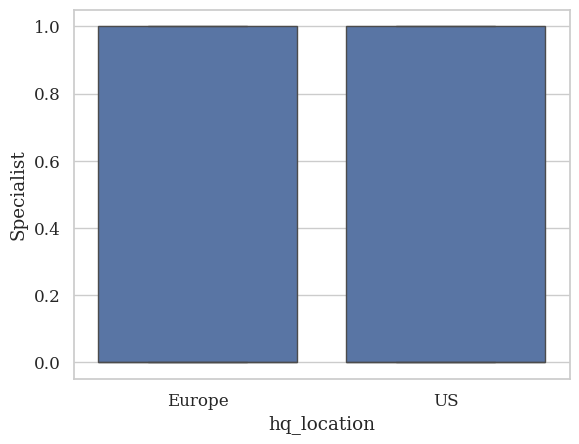

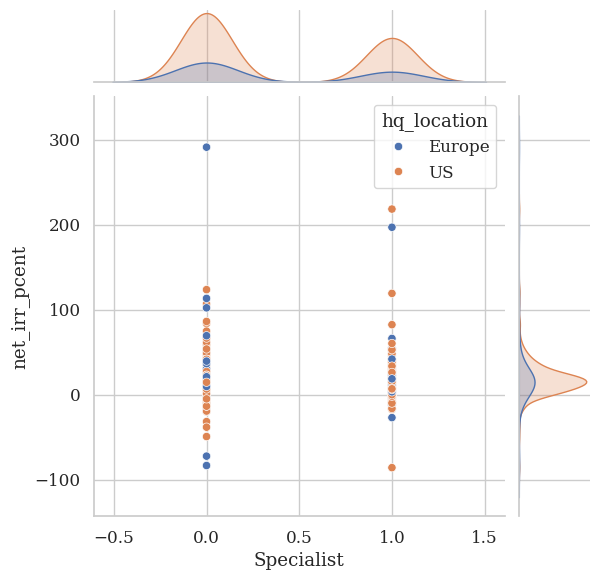

In [31]:
sns.boxplot(x="hq_location", y="Specialist", data=df)
sns.jointplot(x="Specialist", y="net_irr_pcent", hue="hq_location", data=df)

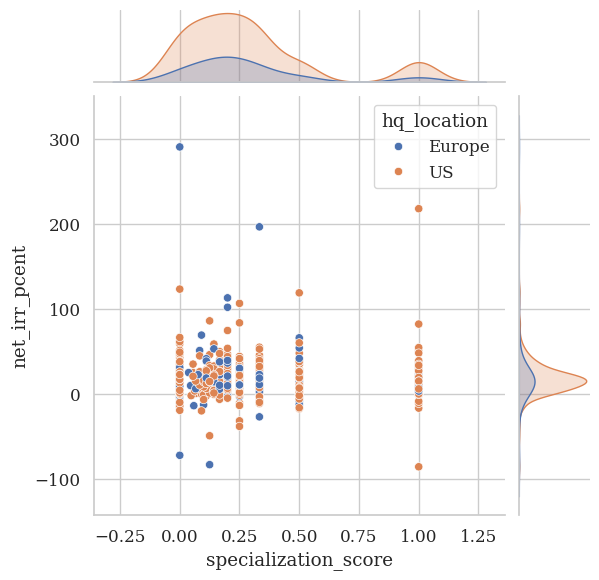

In [32]:
sns.jointplot(x="specialization_score", y="net_irr_pcent", hue="hq_location", data=df)

In [33]:
df["specialization_score"].describe()


count    733.000000
mean       0.289314
std        0.281246
min        0.000000
25%        0.111111
50%        0.250000
75%        0.333333
max        1.000000
Name: specialization_score, dtype: float64

In [34]:
def prepare_model3_specialization_score(df, dependent_var):
    df_model = df[
        df[dependent_var].notna() &
        df["specialization_score"].notna()
    ].copy()

    df_model["Europe_x_specscore"] = df_model["Europe"] * df_model["specialization_score"]

    X = df_model[
        ["Europe", "specialization_score", "Europe_x_specscore"] +
        [f"vintage_{y}" for y in range(2010, 2018)]
    ]
    X = sm.add_constant(X)
    y = df_model[dependent_var]
    clusters = df_model["firm_id"]

    return X, y, clusters


In [35]:
def run_model_3_specialization_score(df, dependent_var):
    X, y, clusters = prepare_model3_specialization_score(df, dependent_var)
    model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": clusters})
    return model


In [36]:
models = {
    "Net IRR": run_model_3_specialization_score(df, "net_irr_pcent"),
    "DPI": run_model_3_specialization_score(df, "distr_dpi_pcent"),
    "TVPI": run_model_3_specialization_score(df, "tvpi_pcent")
}

table = extract_combined_regression_table(
    models=models,
    filename="model3_specialization_score_robustness.tex",
    caption="Regression Results – Model 3 (Continuous Specialization Score)",
    label="tab:model3_specialization_score_robustness",
    return_df=True
)

print("\n=== Model 3 Robustness – Continuous Specialization Score ===")
display(table)



=== Model 3 Robustness – Continuous Specialization Score ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,7.66,4.94,0.121,91.07***,15.87,0.000,160.81***,20.12,0.000
1,Europe,2.68,5.00,0.591,-15.57,20.43,0.446,-25.01,26.64,0.348
2,specialization_score,1.20,4.75,0.800,40.44,27.90,0.147,5.85,36.64,0.873
3,Europe_x_specscore,-8.33,10.34,0.421,-23.03,47.93,0.631,-11.14,53.85,0.836
4,R$^2$,0.020,,,0.066,,,0.025,,
5,N,648,,,672,,,655,,


### Specialisation 2

In [37]:
### Specialisation 2 – "Diversified-only Generalists"
# Generalist only if "diversified" appears in industry; all others Specialist

df["specialisation_diversified"] = df["industry"].apply(
    lambda x: "Generalist" if pd.notna(x) and "diversified" in str(x).lower() else "Specialist"
)

# Dummy coding
df["Specialist_div"] = (df["specialisation_diversified"] == "Specialist").astype(int)
df["Europe_x_Specialist_div"] = df["Europe"] * df["Specialist_div"]

In [38]:
pd.set_option('display.max_rows', 740)
pd.set_option("display.max_colwidth", None)
df[["industry", "specialisation_diversified", "Specialist_div"]]

,industry,specialisation_diversified,Specialist_div
0,Diversified,Generalist,0
1,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,Specialist,1
2,Information Technology;Electronics;Internet;IT Infrastructure;IT Security/Cybersecurity;Telecoms & Media;Media;Telecoms,Specialist,1
3,Transportation Services;Energy & Utilities;Power & Utilities;Renewable Energy;Environmental Services;Information Technology;Semiconductors;Chemicals;Materials,Specialist,1
4,Renewable Energy,Specialist,1
5,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,Specialist,1
6,Information Technology;Internet;Software,Specialist,1
7,Information Technology;Internet;IT Infrastructure;Software,Specialist,1
8,IT Security/Cybersecurity;Semiconductors;Software,Specialist,1
9,Diversified;Information Technology,Generalist,0


In [39]:
df["Specialist_div"].value_counts()

Specialist_div
1    609
0    124
Name: count, dtype: int64

In [40]:
def prepare_model3_div(df, dependent_var):
    df_model = df[df[dependent_var].notna()].copy()
    regressors = ["Europe", "Specialist_div", "Europe_x_Specialist_div"] + [
        f"vintage_{y}" for y in range(2010, 2018)
    ]
    X = sm.add_constant(df_model[regressors])
    y = df_model[dependent_var]
    clusters = df_model["firm_id"]
    return X, y, clusters

def run_model3_div(df, dependent_var):
    X, y, clusters = prepare_model3_div(df, dependent_var)
    model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": clusters})
    return model

In [41]:
# Run and export
models_div = {
    "Net IRR": run_model3_div(df, "net_irr_pcent"),
    "DPI": run_model3_div(df, "distr_dpi_pcent"),
    "TVPI": run_model3_div(df, "tvpi_pcent")
}

table_div = extract_combined_regression_table(
    models=models_div,
    filename="model3_specialisation_diversified.tex",
    caption="Regression Results – Model 3 (Specialization Defined by 'Diversified' Label)",
    label="tab:model3_specialisation_diversified",
    return_df=True
)

print("\n=== Model 3 Robustness – Diversified-only Generalists ===")
display(table_div)



=== Model 3 Robustness – Diversified-only Generalists ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,9.00*,4.73,0.057,92.62***,16.63,0.000,165.56***,27.63,0.000
1,Europe,1.07,14.49,0.941,-53.55***,20.58,0.009,-90.03***,30.43,0.003
2,Specialist_div,-0.88,2.33,0.706,15.87,14.88,0.286,-0.35,27.16,0.990
3,Europe_x_Specialist_div,-0.85,14.94,0.954,35.34,26.19,0.177,72.48**,36.17,0.045
4,R$^2$,0.018,,,0.066,,,0.029,,
5,N,648,,,672,,,655,,


In [42]:
# === Wald tests: Region effect among Specialists in Model 3 (Diversified-only definition) ===
import pandas as pd

def wald_region_effect_specialists_table(df, filename, caption, label):
    # Helper to run model and linear test
    def test_effect(depvar):
        mdl = run_model3_div(df, depvar)
        # Linear restriction: Europe + Europe_x_Specialist_div = 0
        ht = mdl.t_test("Europe + Europe_x_Specialist_div = 0")
        effect = float(ht.effect)                   # estimated linear combo
        se = float(ht.sd)                           # std. error of combo
        pval = float(ht.pvalue)                     # p-value (two-sided)
        return effect, se, pval

    # Run for all three performance metrics
    results = {
        "Net IRR":   test_effect("net_irr_pcent"),
        "DPI":       test_effect("distr_dpi_pcent"),
        "TVPI":      test_effect("tvpi_pcent"),
    }

    # Star formatter like your other tables
    def star(p):
        return '***' if p <= 0.01 else '**' if p <= 0.05 else '*' if p <= 0.1 else ''

    # Build one-row table in your house style
    row = ["Europe effect for Specialists"]
    cols = []
    for metric in ["Net IRR", "DPI", "TVPI"]:
        coef, se, p = results[metric]
        cols += [f"{coef:.2f}{star(p)}", f"{se:.2f}", f"{p:.3f}"]
    row += cols

    columns = ["Variable",
               "Net IRR Coef.", "SE", "p-val",
               "DPI Coef.",     "SE", "p-val",
               "TVPI Coef.",    "SE", "p-val"]

    table = pd.DataFrame([row], columns=columns)

    table.to_latex(
        filename,
        index=False,
        escape=False,
        column_format="l" + "rrr"*3,
        caption=caption,
        label=label
    )
    return table

# Create and save LaTeX table
wald_table = wald_region_effect_specialists_table(
    df=df,
    filename="model3_specialisation_diversified_wald.tex",
    caption="Wald tests for region effect among specialists (Model 3, 'diversified' label definition)",
    label="tab:model3_specialisation_diversified_wald"
)

print("\n=== Wald tests: Europe effect for Specialists ===")
from IPython.display import display
display(wald_table)



=== Wald tests: Europe effect for Specialists ===


/var/folders/_j/dsdv2m7s3mxdjbq7qrpn6dtm0000gn/T/ipykernel_41509/1108371390.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  effect = float(ht.effect)                   # estimated linear combo
/var/folders/_j/dsdv2m7s3mxdjbq7qrpn6dtm0000gn/T/ipykernel_41509/1108371390.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(ht.sd)                           # std. error of combo
/var/folders/_j/dsdv2m7s3mxdjbq7qrpn6dtm0000gn/T/ipykernel_41509/1108371390.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before p

,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,Europe effect for Specialists,0.21,2.64,0.936,-18.21,15.72,0.247,-17.55,20.45,0.391


### Early Stage only

In [43]:
early_stage_types = {"Early Stage", "Early Stage: Seed", "Early Stage: Start-up"}

df_early = df[df["fund_type"].isin(early_stage_types)].copy()


In [44]:
for model_id in range(1, 5):
    models = {
        "Net IRR": run_model(df_early, "net_irr_pcent", model_id),
        "DPI": run_model(df_early, "distr_dpi_pcent", model_id),
        "TVPI": run_model(df_early, "tvpi_pcent", model_id)
    }

    table = extract_combined_regression_table(
        models=models,
        filename=f"model{model_id}_early_combined.tex",
        caption=f"Regression Results – Model {model_id} (Early Stage Only)",
        label=f"tab:model{model_id}_early_combined",
        return_df=True
    )

    print(f"\n=== Model {model_id} (Early Stage Only) ===")
    display(table)



=== Model 1 (Early Stage Only) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,10.11*,6.03,0.094,112.28***,17.38,0.000,166.87***,25.98,0.000
1,Europe,4.77,3.93,0.225,-13.86,21.26,0.515,-12.51,27.06,0.644
2,R$^2$,0.021,,,0.072,,,0.040,,
3,N,376,,,386,,,375,,



=== Model 2 (Early Stage Only) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,-2518.92**,1134.06,0.026,36083.38***,10674.60,0.001,11107.18,12644.68,0.380
1,Europe,2931.16,2948.78,0.320,-15799.47,13597.78,0.245,-8893.46,17615.09,0.614
2,vintage,1.26**,0.56,0.025,-17.86***,5.30,0.001,-5.38,6.28,0.391
3,Europe_x_Vintage,-1.45,1.46,0.321,7.84,6.75,0.245,4.41,8.74,0.614
4,R$^2$,0.019,,,0.043,,,0.003,,
5,N,376,,,386,,,375,,



=== Model 3 (Early Stage Only) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,9.66,6.76,0.153,99.33***,22.57,0.000,159.51***,32.83,0.000
1,Europe,5.59,5.15,0.277,-3.32,29.40,0.910,-3.33,38.08,0.930
2,Specialist,0.73,2.51,0.772,25.96,25.83,0.315,14.34,33.06,0.664
3,Europe_x_Specialist,-2.38,9.14,0.795,-27.29,41.45,0.510,-25.60,53.98,0.635
4,R$^2$,0.021,,,0.076,,,0.040,,
5,N,376,,,386,,,375,,



=== Model 4 (Early Stage Only) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,17.39**,8.81,0.048,99.93**,49.49,0.043,248.11***,72.78,0.001
1,Europe,-10.92,10.95,0.319,-161.30*,93.68,0.085,-320.19***,109.99,0.004
2,log_size,-0.43,2.66,0.872,-4.55,23.04,0.843,-26.23,35.25,0.457
3,log_size_sq,-0.18,0.35,0.602,1.84,2.85,0.518,2.15,4.27,0.615
4,Europe_x_logsize,2.09,6.71,0.756,77.25,49.64,0.120,141.04**,65.73,0.032
5,Europe_x_logsize_sq,0.22,0.97,0.820,-9.36,6.47,0.148,-15.18*,8.88,0.087
6,R$^2$,0.037,,,0.080,,,0.047,,
7,N,354,,,367,,,356,,


### Different Time Periods

In [45]:
import pandas as pd, numpy as np

# Load data
perf    = pd.read_csv("Fund Performance since 1983.csv",   low_memory=False)
info    = pd.read_csv("Fund Details.csv",                  low_memory=False)
details = pd.read_csv("Manger Details.csv",                low_memory=False)

# Coerce numeric columns
num_info = [c for c in info.columns if c.endswith(("usd","eur","pcent"))]
num_perf = [c for c in perf.columns if c.endswith(("usd","eur","pcent"))] + ["multiple"]
info[num_info] = info[num_info].apply(pd.to_numeric, errors="coerce")
perf[num_perf] = perf[num_perf].apply(pd.to_numeric, errors="coerce")

# Filter to VC fund types and apply vintage cut (2000–2019)
VC_CORE = {"Venture (General)", "Early Stage", "Early Stage: Seed", "Early Stage: Start-up"}
info_vc = (
    info.loc[info["fund_type"].isin(VC_CORE)]
        .assign(vintage=lambda d: pd.to_numeric(d["vintage"], errors="coerce"))
        .loc[lambda d: (d["vintage"] >= 1993) & (d["vintage"] <= 2019)]
        .copy()
)

# Merge in firm country and drop irrelevant
info_vc = info_vc.merge(details[["firm_id", "firmcountry"]], on="firm_id", how="left")
info_vc = info_vc.drop(columns=["region"], errors="ignore")

# Keep most recent performance entry per fund
perf_latest = (
    perf.sort_values("date_reported")
        .groupby("fund_id", as_index=False)
        .tail(1)
)

# Merge performance and fund info
df_full_2000_2019 = perf_latest.merge(info_vc, on="fund_id", how="inner")

# Rename vintage column and clean up
df_full_2000_2019["vintage"] = df_full_2000_2019["vintage_x"]
df_full_2000_2019.drop(columns=["vintage_x", "vintage_y"], inplace=True, errors="ignore")

# Create hq_location mapping (US/Europe only)
EUROPE = {'Austria','Belgium','Bulgaria','Croatia','Czech Republic','Cyprus','Denmark',
          'Estonia','Finland','France','Germany','Greece','Hungary','Ireland','Italy',
          'Latvia','Lithuania','Luxembourg','Malta','Netherlands','Norway','Poland',
          'Portugal','Romania','Slovakia','Slovenia','Spain','Sweden','Switzerland',
          'United Kingdom','UK'}
US = {'United States', 'US'}

def hq_location(country):
    if pd.isna(country): return 'Other'
    if country in US:    return 'US'
    if country in EUROPE: return 'Europe'
    return 'Other'

df_full_2000_2019["hq_location"] = df_full_2000_2019["firmcountry"].apply(hq_location)
df_full_2000_2019 = df_full_2000_2019[df_full_2000_2019["hq_location"].isin(["Europe", "US"])].copy()
df_full_2000_2019.reset_index(drop=True, inplace=True)

# Create TVPI
df_full_2000_2019["tvpi_pcent"] = df_full_2000_2019["distr_dpi_pcent"] + df_full_2000_2019["value_rvpi_pcent"]

# Specialisation dummy
df_full_2000_2019["industry_specialisation"] = df_full_2000_2019["industry"].apply(
    lambda x: (
        "Generalist"
        if pd.notna(x) and ("diversified" in x.lower() or x.count(";") >= 3)
        else ("Specialist" if pd.notna(x) else np.nan)
    )
)

# Fund age
df_full_2000_2019["fund_age_at_report"] = pd.to_datetime(df_full_2000_2019["date_reported"]).dt.year - df_full_2000_2019["vintage"]

# Final selection
df_full_2000_2019 = df_full_2000_2019[[
    "firm_id", "fund_id", "date_reported", "vintage", "distr_dpi_pcent",
    "net_irr_pcent", "tvpi_pcent", "value_rvpi_pcent", "multiple", "fund_type",
    "final_size_usd", "fund_status", "fund_focus", "hq_location", "industry",
    "firmcountry", "industry_specialisation", "fund_age_at_report"
]]


In [46]:
# Define Europe dummy
df_full_2000_2019["Europe"] = (df_full_2000_2019["hq_location"] == "Europe").astype(int)

# Define Specialist dummy
df_full_2000_2019["Specialist"] = (df_full_2000_2019["industry_specialisation"] == "Specialist").astype(int)

# Create log fund size and interaction terms for Model 4
df_full_2000_2019 = df_full_2000_2019[df_full_2000_2019["final_size_usd"].notna() & (df_full_2000_2019["final_size_usd"] > 0)].copy()
df_full_2000_2019["log_size"] = np.log(df_full_2000_2019["final_size_usd"])
df_full_2000_2019["log_size_sq"] = df_full_2000_2019["log_size"] ** 2
df_full_2000_2019["Europe_x_logsize"] = df_full_2000_2019["Europe"] * df_full_2000_2019["log_size"]
df_full_2000_2019["Europe_x_logsize_sq"] = df_full_2000_2019["Europe"] * df_full_2000_2019["log_size_sq"]

# Vintage dummies for Models 1 and 3
vintage_dummies = pd.get_dummies(df_full_2000_2019["vintage"], prefix="vintage", drop_first=False)
df_full_2000_2019 = pd.concat([df_full_2000_2019, vintage_dummies.astype(int)], axis=1)


In [47]:
# Subset to 1993–2008 and run all models
df_1993_2008 = df_full_2000_2019[df_full_2000_2019["vintage"].between(1993, 2008)].copy()

for model_id in range(1, 5):
    models = {
        "Net IRR": run_model(df_1993_2008, "net_irr_pcent", model_id),
        "DPI": run_model(df_1993_2008, "distr_dpi_pcent", model_id),
        "TVPI": run_model(df_1993_2008, "tvpi_pcent", model_id)
    }

    print(f"\n=== Regression Results – Model {model_id} (1993–2008) ===")
    table = extract_combined_regression_table(
        models=models,
        filename=f"model{model_id}_1993_2008_combined.tex",
        caption=f"Regression Results – Model {model_id} (1993–2008)",
        label=f"tab:model{model_id}_1993_2008_combined",
        return_df=True
    )
    display(table)


=== Regression Results – Model 1 (1993–2008) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,12.94***,1.89,0.000,168.42***,11.52,0.000,193.84***,12.03,0.000
1,Europe,-6.42***,2.30,0.005,-58.05***,15.98,0.000,-48.87***,15.43,0.002
2,R$^2$,0.003,,,0.008,,,0.006,,
3,N,800,,,931,,,912,,



=== Regression Results – Model 2 (1993–2008) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,5966.57***,1063.63,0.000,25372.75***,8121.75,0.002,18388.69**,8211.32,0.025
1,Europe,-5418.86***,1283.15,0.000,-11351.70,10333.82,0.272,-12964.75,10349.38,0.210
2,vintage,-2.97***,0.53,0.000,-12.59***,4.06,0.002,-9.09**,4.10,0.027
3,Europe_x_Vintage,2.70***,0.64,0.000,5.64,5.16,0.274,6.45,5.17,0.212
4,R$^2$,0.073,,,0.041,,,0.022,,
5,N,800,,,931,,,912,,



=== Regression Results – Model 3 (1993–2008) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,15.72***,3.26,0.000,180.91***,17.37,0.000,205.30***,17.78,0.000
1,Europe,-9.30**,3.71,0.012,-69.88***,22.75,0.002,-57.94***,22.02,0.009
2,Specialist,-5.60,3.72,0.133,-25.65,20.51,0.211,-23.56,20.77,0.257
3,Europe_x_Specialist,5.80,4.48,0.196,24.27,27.37,0.375,18.58,26.57,0.484
4,R$^2$,0.007,,,0.010,,,0.007,,
5,N,800,,,931,,,912,,



=== Regression Results – Model 4 (1993–2008) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,14.69,15.48,0.343,268.98,166.64,0.107,311.43*,169.43,0.066
1,Europe,22.18,25.46,0.384,-113.69,219.06,0.604,-69.67,214.15,0.745
2,log_size,4.95,6.11,0.417,-22.04,66.32,0.740,-21.84,67.25,0.745
3,log_size_sq,-1.02*,0.60,0.090,0.27,6.36,0.966,-0.43,6.42,0.946
4,Europe_x_logsize,-19.23*,11.49,0.094,1.11,94.47,0.991,-22.04,91.94,0.811
5,Europe_x_logsize_sq,2.57**,1.28,0.045,1.97,10.08,0.845,5.00,9.75,0.609
6,R$^2$,0.019,,,0.015,,,0.018,,
7,N,800,,,931,,,912,,


In [48]:
# Subset to 2009–2019
df_2009_2019 = df_full_2000_2019[df_full_2000_2019["vintage"].between(2009, 2019)].copy()

# Run only for Net IRR
for model_id in range(1, 5):
    model = run_model(df_2009_2019, "net_irr_pcent", model_id)

    print(f"\n=== Regression Results – Model {model_id} (2009–2019) – Net IRR Only ===")
    table = extract_combined_regression_table(
        models={"Net IRR": model},
        filename=f"model{model_id}_2009_2019_netirr.tex",
        caption=f"Regression Results – Model {model_id} (2009–2019) – Net IRR",
        label=f"tab:model{model_id}_2009_2019_netirr",
        return_df=True
    )
    display(table)



=== Regression Results – Model 1 (2009–2019) – Net IRR Only ===


,Variable,Net IRR Coef.,SE,p-val
0,const,18.97***,1.56,0.000
1,Europe,-2.05,2.14,0.339
2,R$^2$,0.009,,
3,N,846,,



=== Regression Results – Model 2 (2009–2019) – Net IRR Only ===


,Variable,Net IRR Coef.,SE,p-val
0,const,-1398.33**,606.48,0.021
1,Europe,476.73,1294.64,0.713
2,vintage,0.70**,0.30,0.019
3,Europe_x_Vintage,-0.24,0.64,0.712
4,R$^2$,0.010,,
5,N,846,,



=== Regression Results – Model 3 (2009–2019) – Net IRR Only ===


,Variable,Net IRR Coef.,SE,p-val
0,const,19.32***,1.72,0.000
1,Europe,-2.62,2.67,0.327
2,Specialist,-0.89,1.86,0.632
3,Europe_x_Specialist,1.47,4.01,0.713
4,R$^2$,0.010,,
5,N,846,,



=== Regression Results – Model 4 (2009–2019) – Net IRR Only ===


,Variable,Net IRR Coef.,SE,p-val
0,const,17.59***,2.69,0.000
1,Europe,-3.29,10.45,0.753
2,log_size,2.92**,1.32,0.027
3,log_size_sq,-0.51***,0.17,0.003
4,Europe_x_logsize,-3.86,5.36,0.471
5,Europe_x_logsize_sq,0.86,0.71,0.227
6,R$^2$,0.023,,
7,N,846,,


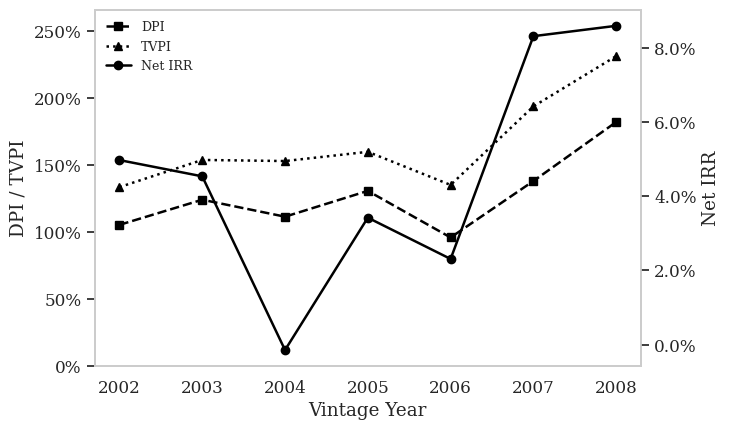

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Aggregate by vintage
performance_by_vintage = df_1993_2008[df_1993_2008["vintage"] > 2001].groupby("vintage")[["net_irr_pcent", "distr_dpi_pcent", "tvpi_pcent"]].mean().reset_index()

# Plot setup
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
plt.rcParams["font.family"] = "serif"

# Left y-axis: DPI & TVPI
ax1.plot(
    performance_by_vintage["vintage"], performance_by_vintage["distr_dpi_pcent"],
    color="black", linestyle="--", marker="s", label="DPI", linewidth=1.8
)
ax1.plot(
    performance_by_vintage["vintage"], performance_by_vintage["tvpi_pcent"],
    color="black", linestyle=":", marker="^", label="TVPI", linewidth=1.8
)
ax1.set_xlabel("Vintage Year")
ax1.set_ylabel("DPI / TVPI")
ax1.set_ylim(0, performance_by_vintage[["distr_dpi_pcent", "tvpi_pcent"]].max().max() * 1.15)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Right y-axis: IRR
ax2 = ax1.twinx()
ax2.plot(
    performance_by_vintage["vintage"], performance_by_vintage["net_irr_pcent"],
    color="black", linestyle="-", marker="o", label="Net IRR", linewidth=1.8
)
ax2.set_ylabel("Net IRR")
ax2.yaxis.set_major_formatter(PercentFormatter())

# Turn off grid lines
ax1.grid(False)
ax2.grid(False)

# Combine legends manually
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9, frameon=False)

# Final formatting
fig.tight_layout()
plt.show()


### Including fund age at reporting time

In [50]:
# Filter to funds older than 8 years
df_older = df[df["fund_age_at_report"] > 8].copy()

# Run models and extract tables for the 8+ years subset
for model_id in range(1, 5):
    models = {
        "Net IRR": run_model(df_older, "net_irr_pcent", model_id),
        "DPI": run_model(df_older, "distr_dpi_pcent", model_id),
        "TVPI": run_model(df_older, "tvpi_pcent", model_id)
    }

    table = extract_combined_regression_table(
        models=models,
        filename=f"model{model_id}_older_combined.tex",
        caption=f"Regression Results – Model {model_id} (Funds > 8 Years Old)",
        label=f"tab:model{model_id}_older_combined",
        return_df=True
    )

    print(f"\n=== Model {model_id} (Funds > 8 Years Old) ===")
    display(table)



=== Model 1 (Funds > 8 Years Old) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,7.21***,2.38,0.002,130.09***,15.22,0.000,169.41***,21.01,0.000
1,Europe,4.81,4.22,0.254,-25.70,28.87,0.373,-17.34,34.30,0.613
2,R$^2$,0.038,,,0.037,,,0.025,,
3,N,276,,,295,,,290,,



=== Model 2 (Funds > 8 Years Old) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,-456.87,1261.45,0.717,27279.21**,11834.89,0.021,-10816.25,16908.73,0.522
1,Europe,84.51,2653.81,0.975,-35781.40,28791.91,0.214,-8266.70,32763.63,0.801
2,vintage,0.23,0.63,0.708,-13.48**,5.88,0.022,5.51,8.40,0.512
3,Europe_x_Vintage,-0.04,1.32,0.976,17.77,14.31,0.214,4.10,16.29,0.801
4,R$^2$,0.011,,,0.013,,,0.002,,
5,N,276,,,295,,,290,,



=== Model 3 (Funds > 8 Years Old) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,5.27*,3.03,0.082,120.76***,20.92,0.000,175.21***,28.28,0.000
1,Europe,10.68*,6.28,0.089,-7.65,36.03,0.832,-7.94,45.12,0.860
2,Specialist,2.90,3.42,0.396,18.94,31.04,0.542,-13.53,37.20,0.716
3,Europe_x_Specialist,-17.56**,8.48,0.038,-56.07,45.58,0.219,-31.78,59.92,0.596
4,R$^2$,0.059,,,0.041,,,0.027,,
5,N,276,,,295,,,290,,



=== Model 4 (Funds > 8 Years Old) ===


,Variable,Net IRR Coef.,SE,p-val,DPI Coef.,SE,p-val,TVPI Coef.,SE,p-val
0,const,6.33*,3.29,0.054,44.04,37.42,0.239,130.72**,63.70,0.040
1,Europe,-6.54,17.50,0.709,-64.63,147.93,0.662,-216.59,155.11,0.163
2,log_size,0.77,1.79,0.666,33.01*,17.75,0.063,33.75,30.34,0.266
3,log_size_sq,-0.06,0.22,0.803,-2.65,2.08,0.202,-4.36,3.50,0.213
4,Europe_x_logsize,5.09,9.97,0.610,3.50,74.33,0.962,94.25,87.00,0.279
5,Europe_x_logsize_sq,-0.67,1.31,0.607,1.17,9.71,0.904,-11.41,11.77,0.332
6,R$^2$,0.039,,,0.054,,,0.032,,
7,N,263,,,280,,,276,,


### Checking Statistical Equivalence

In [55]:
from scipy import stats
from statsmodels.stats.weightstats import ttost_ind

# Gruppen extrahieren
eu = df[df["hq_location"] == "Europe"]["net_irr_pcent"].dropna()
us = df[df["hq_location"] == "US"]["net_irr_pcent"].dropna()

# TOST
res = ttost_ind(eu, us, low=-3, upp=3, usevar='unequal')

# Mittelwertsdifferenz & Standardfehler
mean_diff = eu.mean() - us.mean()
se_diff = np.sqrt(eu.var(ddof=1)/len(eu) + us.var(ddof=1)/len(us))

# Freiheitsgrade konservativ (Welch-Approximation könnte genauer sein)
df_min = min(len(eu), len(us)) - 1

# Kritischer t-Wert für 95%-CI
t_crit = stats.t.ppf(1 - 0.025, df=df_min)

# Konfidenzintervall
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# Ausgabe
print("Test for Statistical Equivalence net-IRR between the USA and Europe")
print(f"TOST p-value: {res[0]:.4f}")
print(f"Test 1 (Diff > -3): t = {res[1][0]:.2f}, p = {res[1][1]:.4f}")
print(f"Test 2 (Diff <  3): t = {res[2][0]:.2f}, p = {res[2][1]:.4f}")
print(f"95%-Konfidenzintervall: [{ci_low:.2f}, {ci_high:.2f}] pp")
print(f"Mittelwertsdifferenz: {mean_diff:.2f} pp")

if res[1][1] < 0.05 and res[2][1] < 0.05:
    print("→ Ergebnis: Gleichwertigkeit belegt (TOST bestanden)")
else:
    print("→ Ergebnis: Keine Gleichwertigkeit belegt (TOST nicht bestanden)")


Test for Statistical Equivalence net-IRR between the USA and Europe
TOST p-value: 0.2040
Test 1 (Diff > -3): t = 1.24, p = 0.1077
Test 2 (Diff <  3): t = -0.83, p = 0.2040
95%-Konfidenzintervall: [-5.12, 6.32] pp
Mittelwertsdifferenz: 0.60 pp
→ Ergebnis: Keine Gleichwertigkeit belegt (TOST nicht bestanden)


In [58]:
from scipy import stats
from statsmodels.stats.weightstats import ttost_ind

# Gruppen extrahieren
eu = df[df["hq_location"] == "Europe"]["tvpi_pcent"].dropna()
us = df[df["hq_location"] == "US"]["tvpi_pcent"].dropna()

# TOST
res = ttost_ind(eu, us, low=-30, upp=30, usevar='unequal')

# Mittelwertsdifferenz & Standardfehler
mean_diff = eu.mean() - us.mean()
se_diff = np.sqrt(eu.var(ddof=1)/len(eu) + us.var(ddof=1)/len(us))

# Freiheitsgrade konservativ (Welch-Approximation könnte genauer sein)
df_min = min(len(eu), len(us)) - 1

# Kritischer t-Wert für 95%-CI
t_crit = stats.t.ppf(1 - 0.025, df=df_min)

# Konfidenzintervall
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# Ausgabe
print("Test for Statistical Equivalence TVPI between the USA and Europe")
print(f"TOST p-value: {res[0]:.4f}")
print(f"Test 1 (Diff > -3): t = {res[1][0]:.2f}, p = {res[1][1]:.4f}")
print(f"Test 2 (Diff <  3): t = {res[2][0]:.2f}, p = {res[2][1]:.4f}")
print(f"95%-Konfidenzintervall: [{ci_low:.2f}, {ci_high:.2f}] pp")
print(f"Mittelwertsdifferenz: {mean_diff:.2f} pp")

if res[1][1] < 0.05 and res[2][1] < 0.05:
    print("→ Ergebnis: Gleichwertigkeit belegt (TOST bestanden)")
else:
    print("→ Ergebnis: Keine Gleichwertigkeit belegt (TOST nicht bestanden)")


Test for Statistical Equivalence TVPI between the USA and Europe
TOST p-value: 0.4541
Test 1 (Diff > -3): t = 0.12, p = 0.4541
Test 2 (Diff <  3): t = -3.47, p = 0.0003
95%-Konfidenzintervall: [-61.12, 4.99] pp
Mittelwertsdifferenz: -28.07 pp
→ Ergebnis: Keine Gleichwertigkeit belegt (TOST nicht bestanden)
